In [1]:
from dataclasses import dataclass, field, InitVar
from math import tau, cos, sin
import numpy as np
import hashlib
from collections.abc import Iterable, Generator
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator

In [2]:
def to_decibel(p: np.ndarray, p_0: np.ndarray) -> np.ndarray:
    return 10.0 * np.log10((p + 1e-10) / (p_0 + 1e-10))


def _filter_pass(state: tuple[float, float], sample: float, omega: complex) -> tuple[float, float]:
    d1, d2 = state
    y = sample + omega.real * d1 - d2
    return y, d1


def _power(state: tuple[float, float], omega: complex) -> float:
    d1, d2 = state
    return pow(d1, 2) + pow(d2, 2) - omega.real * d1 * d2


@dataclass(slots=True, frozen=True)
class State:
    omega: complex
    state: tuple[float, float]

    def power(self) -> float:
        return _power(self.state, self.omega)


@dataclass(slots=True)
class Goertzel:
    sample_rate: InitVar[int]
    frequency: InitVar[int]
    window_size: int
    oscillator_activation_threshold: float = field(default=0.5)
    omega: complex = field(init=False)
    state: tuple[float, float] = field(init=False, default=(0.0, 0.0))
    counter: int = field(init=False, default=0)

    def __post_init__(self, sample_rate: int, frequency: int) -> None:
        phi = tau * frequency / sample_rate
        self.omega = complex(2 * cos(phi), sin(phi))

    def reset(self) -> None:
        self.state = (0.0, 0.0)

    def add_sample(self, sample: float) -> State:
        self.state = _filter_pass(self.state, sample, self.omega)

        # Manage the NCO and the filter state
        state = self.state
        if self.counter < 0 and _power(self.state, self.omega) >= self.oscillator_activation_threshold:
            self.counter = 1
        elif self.counter >= 0:
            self.counter = (self.counter + 1) % self.window_size
        if self.counter == 0:
            self.reset()

        return State(self.omega, state,)

    def consume(self, samples: Iterable[float]) -> Generator[State, None, None]:
        return (self.add_sample(sample) for sample in samples)


@dataclass(slots=True)
class Oscillator:
    period_length: int
    counter: int = field(init=False, default=0)

    def __iter__(self) -> 'Oscillator':
        return self

    def __next__(self) -> int:
        c = self.counter
        self.counter = (self.counter + 1) % self.period_length
        return c


@dataclass(slots=True)
class BitClock:
    sample_rate: InitVar[int]
    mark_frequency: InitVar[int]
    space_frequency: InitVar[int]
    oscillator_activation_threshold: float = field(default=0.5)
    mark: Goertzel = field(init=False)
    space: Goertzel = field(init=False)

    def __post_init__(self, sample_rate: int, mark_frequency: int, space_frequency: int) -> None:
        self.mark = Goertzel(sample_rate, mark_frequency)
        self.space = Goertzel(sample_rate, space_frequency)

In [3]:
with open('modulated-normalized-six-bits.npz', mode='rb') as f:
    digest = hashlib.file_digest(f, "sha256")
    assert digest.hexdigest() == "6e26e3d25dcfd5b5856dbd33ca745258842eaca7ee6bb578d52c60f18802cec1"
    f.seek(0)
    with np.load(f, allow_pickle=False) as data:
        source = data['source']
        modulated = data['modulated']

print(f"{source.shape=}, {source.dtype=}")
print(f"{modulated.shape=}, {modulated.dtype=}")

source.shape=(6,), source.dtype=dtype('bool')
modulated.shape=(192,), modulated.dtype=dtype('float64')


In [4]:
# Introduce zeros at the beginning and end, then add noise
np.random.seed(0)
def apply_noise(signal: np.ndarray) -> np.ndarray:
    s = np.concat([np.zeros((20,)), signal, np.zeros((20,))])
    n = 0.1 * np.random.randn(s.shape[0])
    return s + n

noisy = apply_noise(modulated)

In [5]:
mark_states = list(Goertzel(9600, 2400, 32).consume(noisy))
mark_d1 = np.array([state.state[0] for state in mark_states])
mark_d2 = np.array([state.state[1] for state in mark_states])
mark_power = np.array([state.power() for state in mark_states])

In [6]:
space_states = list(Goertzel(9600, 1200, 32).consume(noisy))
space_d1 = np.array([state.state[0] for state in space_states])
space_d2 = np.array([state.state[1] for state in space_states])
space_power = np.array([state.power() for state in space_states])

Text(0.5, 1.0, 'Spectral Power Ratio (dB)')

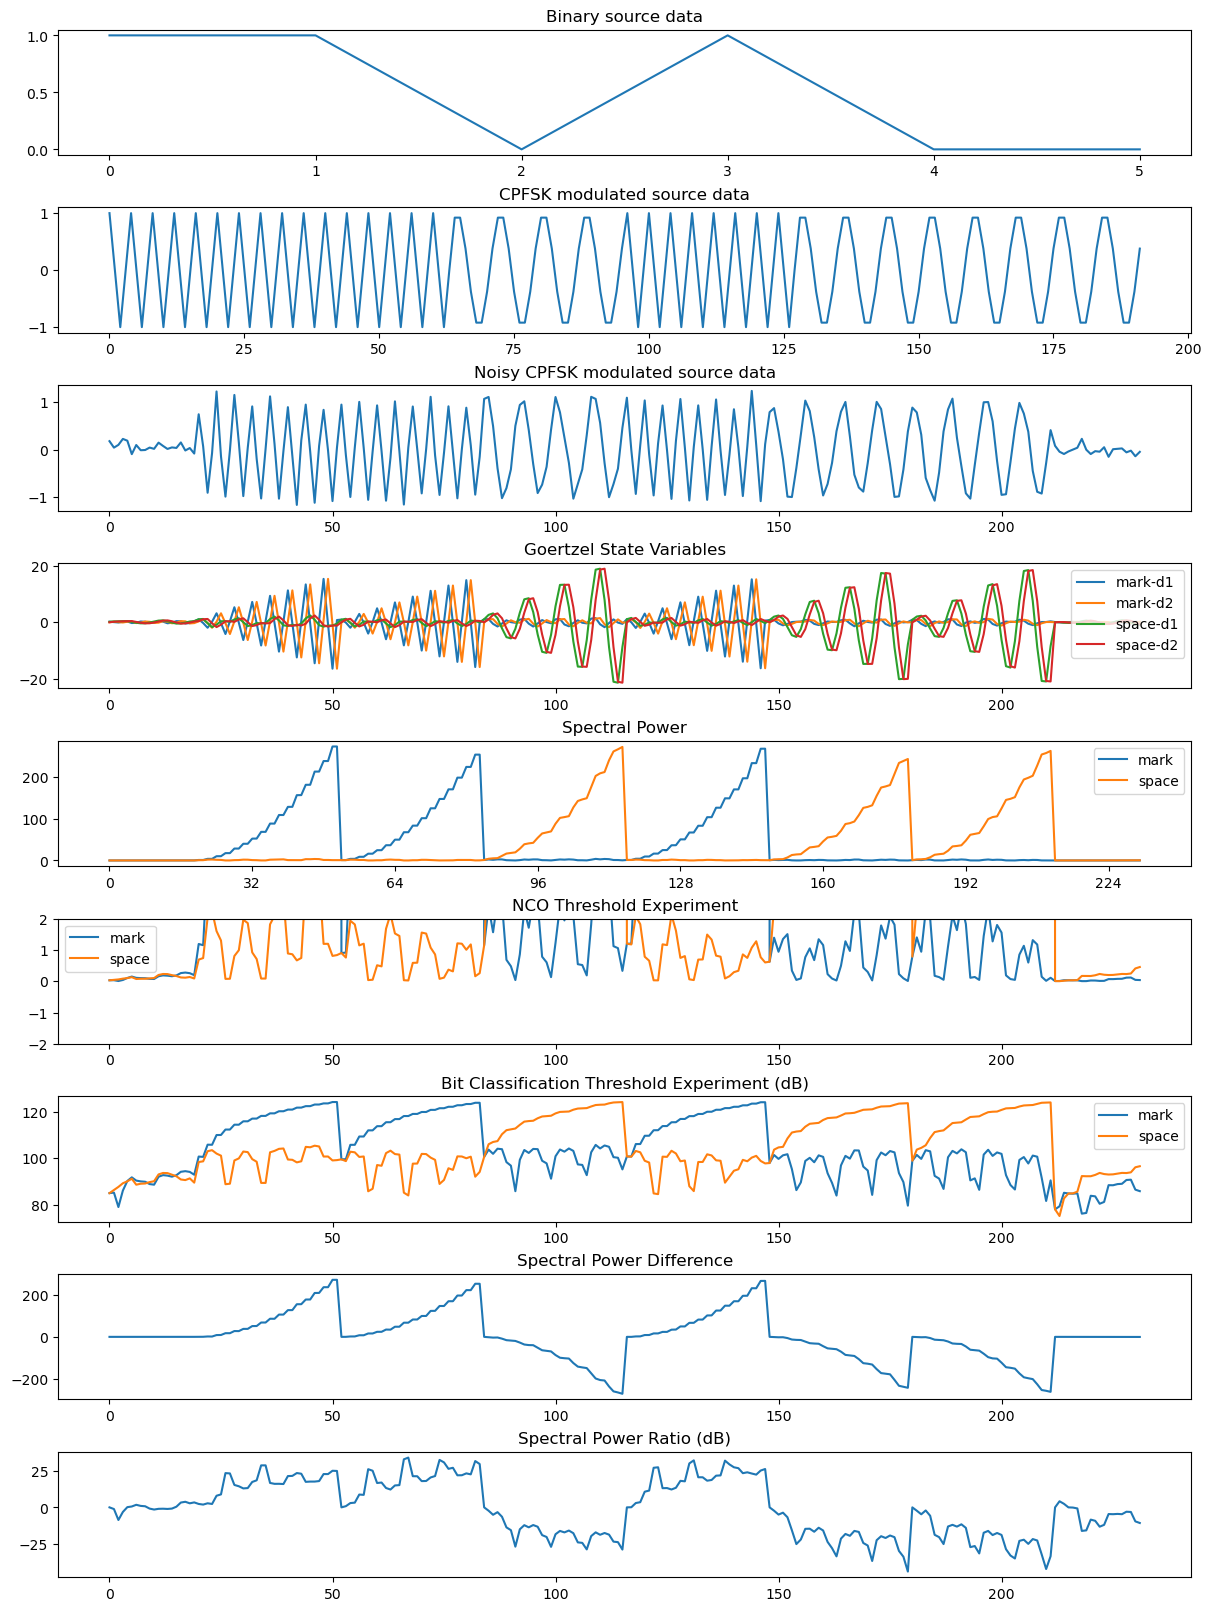

In [7]:
fig = plt.figure(figsize=(12, 16), dpi=100, layout='constrained')
axs = fig.subplot_mosaic([
    ['source'], 
    ['modulated'],
    ['noisy'],
    ['state'],
    ['power'],
    ['nco'],
    ['bit'],
    ['power_diff'],
    ['power_ratio'],
])
axs['source'].plot(source)
axs['source'].set_title('Binary source data')
axs['modulated'].plot(modulated)
axs['modulated'].set_title('CPFSK modulated source data')
axs['noisy'].plot(noisy)
axs['noisy'].set_title('Noisy CPFSK modulated source data')
axs['state'].plot(mark_d1, label='mark-d1')
axs['state'].plot(mark_d2, label='mark-d2')
axs['state'].plot(space_d1, label='space-d1')
axs['state'].plot(space_d2, label='space-d2')
axs['state'].legend()
axs['state'].set_title('Goertzel State Variables')
axs['power'].plot(mark_power, label='mark')
axs['power'].plot(space_power, label='space')
axs['power'].xaxis.set_major_locator(MultipleLocator(32))
axs['power'].legend()
axs['power'].set_title('Spectral Power')
axs['nco'].plot(mark_power, label='mark')
axs['nco'].plot(space_power, label='space')
axs['nco'].set_ylim(bottom=-2, top=2)
axs['nco'].legend()
axs['nco'].set_title('NCO Threshold Experiment')
axs['bit'].plot(to_decibel(mark_power, 0), label='mark')
axs['bit'].plot(to_decibel(space_power, 0), label='space')
axs['bit'].legend()
axs['bit'].set_title('Bit Classification Threshold Experiment (dB)')
axs['power_diff'].plot(mark_power - space_power)
axs['power_diff'].set_title('Spectral Power Difference')
axs['power_ratio'].plot(to_decibel(mark_power, space_power))
axs['power_ratio'].set_title('Spectral Power Ratio (dB)')